# scSVC reconstructs whole-genome profiles of Xenium datasets and defines fine-grained subtypes of T cells

## Notebook Guide

**Purpose.** Analyze reconstructed T-cell states and compare sc-SVC signals against raw Xenium measurements.

**Inputs.** Frozen `../../output/P2CRC_Xenium/T/spatial.h5ad` and `expr.h5ad`. Reconstruction starts from a spatial AnnData with a cell-by-gene matrix and `obsm["spatial"]`, plus a reference AnnData sharing gene names and carrying `obs["Level1"]`; `Level2` is useful downstream but not required to start the route.

**Reconstruction command.** `python reconstruct.py --config configs/application/Xenium_T.yaml`

**Expected reconstructed outputs.** `output/P2CRC_Xenium/T/spatial.h5ad` and `output/P2CRC_Xenium/T/expr.h5ad`.

**Analysis workflow.**
1. Load reconstructed SVCs
2. Visualize T-cell subtypes
3. Quantify differential genes and pathways
4. Compare raw and reconstructed signals

**Outputs.** Subtype maps and unique spatial and expression comparison artifacts under `../../output/P2CRC_Xenium_analysis/T/`.

**Execution and evidence boundary.** This notebook includes a validated Python 3.10 execution snapshot from a clean installed wheel and frozen inputs. Runtime/schema/artifact evidence does not establish biological validity; the raw receipt and execution log remain the technical authority.


In [2]:
import os
os.environ.setdefault("TQDM_DISABLE", "1")
os.environ.setdefault("TQDM_MININTERVAL", "60")

try:
    from IPython import get_ipython
    _ipython = get_ipython()
    if _ipython is not None:
        _ipython.run_line_magic("matplotlib", "inline")
except Exception:
    pass

data_root = "../../output/P2CRC_Xenium"
case_dir = f"{data_root}/T"
analysis_output_dir = os.environ.get("REVISE_ANALYSIS_OUTPUT_ROOT", "../../output/P2CRC_Xenium_analysis/T")
output_dir = analysis_output_dir
os.makedirs(f"{output_dir}/sc_SVC", exist_ok=True)
select_ct = "T"


Matplotlib is building the font cache; this may take a moment.


## Load Reconstructed SVCs

Load the executed reconstruction outputs that drive the downstream figures.


In [3]:
import os
import scanpy as sc

from revise.backend.runners.sc_svc_application import ScSVCAnalysis
import pandas as pd
import revise.analysis.bio as _revise_bio
from revise.analysis.advanced.enrichment import get_enrichment_local as _strict_get_enrichment_local

_revise_bio.get_enrichment = _strict_get_enrichment_local


sc_svc_expr = sc.read_h5ad(f"{case_dir}/expr.h5ad")
sc_svc_spatial = sc.read_h5ad(f"{case_dir}/spatial.h5ad")

sc_svc_analysis = ScSVCAnalysis(sc_svc_spatial, sc_svc_expr, 
                            "SVC_cluster")
# Legacy notebooks use these aliases in downstream result and plotting cells.
sc_SVC_adata = sc_svc_analysis.sc_SVC_adata_spatial.copy()
adata_sp = sc_svc_analysis.sc_SVC_adata_spatial.copy()
adata_sc = sc_svc_analysis.sc_SVC_adata_expr.copy()


/private/tmp/revise-notebook-acceptance-v5-venv/lib/python3.10/site-packages/torch/cuda/__init__.py:64: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


/private/tmp/revise-notebook-acceptance-v5-venv/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


/private/tmp/revise-notebook-acceptance-v5-venv/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


/private/tmp/revise-notebook-acceptance-v5-venv/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


Conducting differential expression analysis...


In [4]:
cm_df = sc_svc_analysis.get_cm_df("Level2")
cm_df

/private/tmp/revise-notebook-acceptance-v5-venv/lib/python3.10/site-packages/revise/backend/runners/sc_svc_application.py:84: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = self.sc_SVC_adata_expr.obs.groupby([self.cluster_col, sub_cell_type_col]).size()


Level2,CD4T,CD8T,NK,Tprolif
SVC_cluster,,,,
0,553,6,0,57
1,22,3,0,262
2,164,1098,99,73
3,498,85,1,7
4,712,50,0,32
5,819,7,0,31
6,197,99,53,36


/var/folders/fd/3dt4wzz12bx4ycmm4k_gp_km0000gn/T/ipykernel_77130/2520313853.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', lut=10)


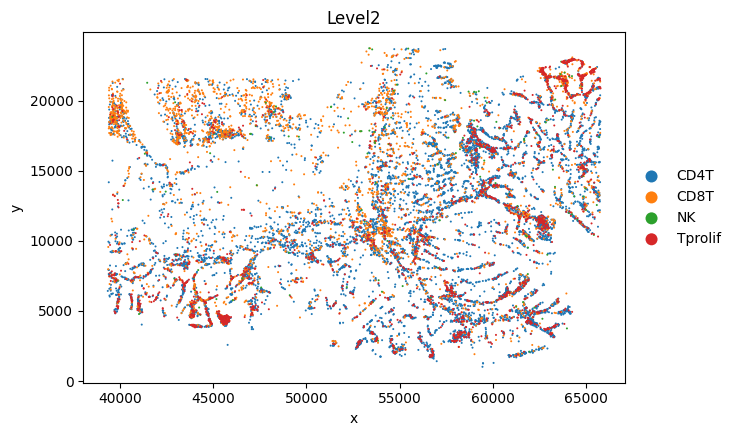

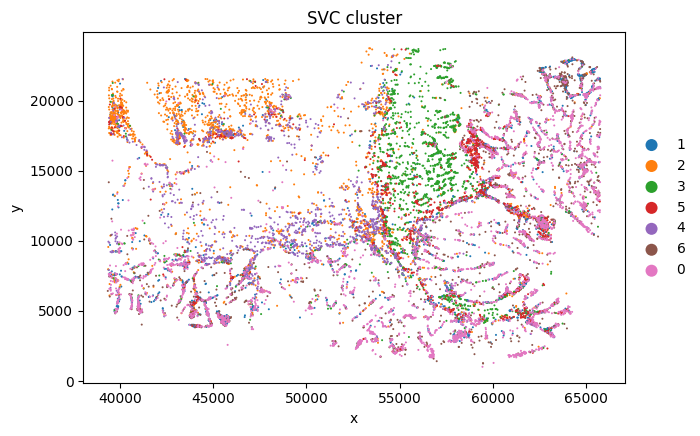

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 

size = None
cmap = plt.cm.get_cmap('tab20', lut=10)
palette = [mcolors.to_hex(cmap(i)) for i in range(cmap.N)]

sc.pl.scatter(sc_svc_analysis.sc_SVC_adata_spatial, x="x", y="y",
              color='Level2',
              size=size)
desired_order = ['1', '2', '3', '5', '4', '6', '0']  # for better visualization
current_categories = sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].cat.categories.astype(str).tolist()
ordered_categories = [cat for cat in desired_order if cat in current_categories]
ordered_categories += [cat for cat in current_categories if cat not in ordered_categories]
sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'] = (
    sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].cat.reorder_categories(ordered_categories, ordered=True)
)
sc.pl.scatter(sc_svc_analysis.sc_SVC_adata_spatial, x="x", y="y",
              color='SVC_cluster',
              size=size)

## Spatial Subtype Maps

Display reconstructed spatial cell states and side-by-side annotation comparisons.


<Figure size 1000x800 with 0 Axes>

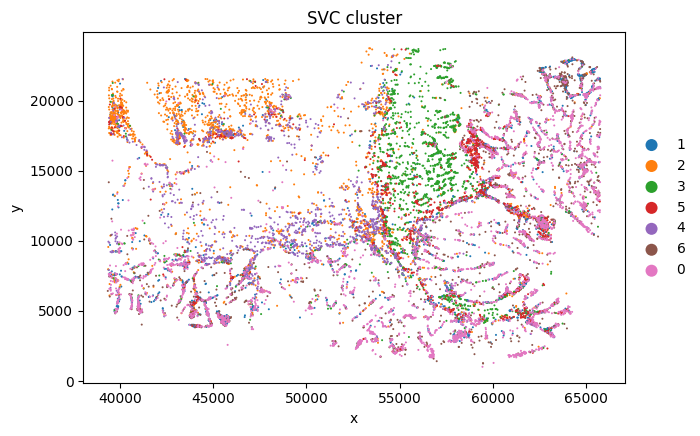

<Figure size 1000x1600 with 0 Axes>

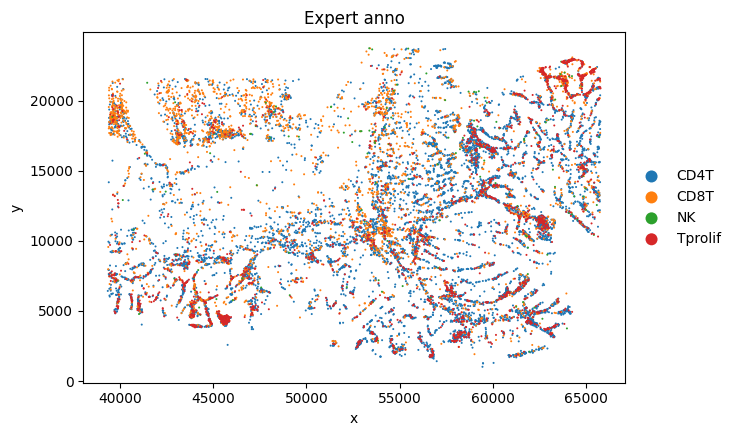

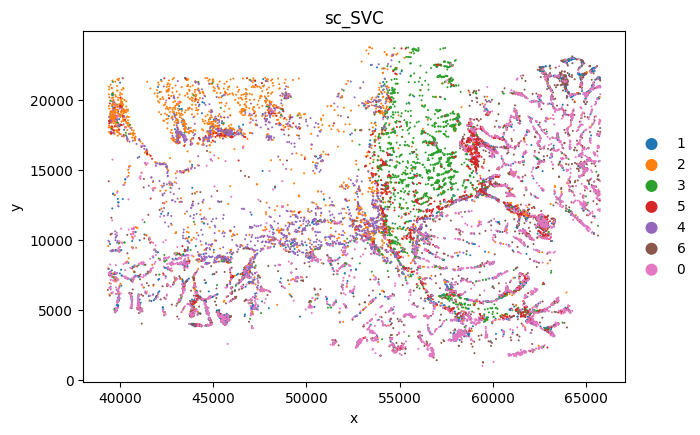

In [6]:
import matplotlib.pyplot as plt
def plot_sc_SVC(adata, color, title = None, file_name = None):

    colors = color if isinstance(color, (list, tuple)) else [color]
    titles = title if isinstance(title, (list, tuple)) else [title] * len(colors)
    plt.figure(figsize=(10, 8*len(colors)))
    for color_key, plot_title in zip(colors, titles):
        sc.pl.scatter(
            adata, x="x", y="y",
            color=color_key,
            title=plot_title, show=False,
        )
    plt.savefig(file_name, dpi = 300)
    plt.show()
    plt.close()

sc_SVC_file_name = f"{output_dir}/sc_SVC.png"
plot_sc_SVC(sc_svc_analysis.sc_SVC_adata_spatial, color='SVC_cluster',
            file_name=sc_SVC_file_name
            )

sc_SVC_file_name = f"{output_dir}/compare.png"
plot_sc_SVC(sc_svc_analysis.sc_SVC_adata_spatial, color=['Level2','SVC_cluster'],
            title=["Expert anno", "sc_SVC"],
            file_name=sc_SVC_file_name
            )

## bioinfo analysis

In [7]:
cluster_nums = ['1','3','5']
fc_threshold = 1
pathway_num = 20
gene_num = 60
geneset_file = ["./pathway/h.all.v2025.1.Hs.symbols.gmt"]
pathway_file_name = f"{output_dir}/pathway_{fc_threshold}_{pathway_num}.txt"
all_pathway = sc_svc_analysis.get_pathway_conclusion(
    cluster_nums, fc_threshold=fc_threshold, pathway_num=pathway_num, gene_num=gene_num, geneset_file=geneset_file, normalize=True)
all_pathway.to_csv(pathway_file_name)
all_pathway

Conducting differential expression analysis...
Cluster 1: 
Up-regulated genes: ['MKI67', 'TYMS', 'HIST1H1B', 'TUBB', 'HMGB2', 'HIST1H1C', 'ACTB', 'RRM2', 'LMNB1', 'TOP2A', 'HIST1H4C', 'PFN1', 'VIM', 'CFL1', 'HIST1H1D', 'TPX2', 'NUSAP1', 'NCAPG2', 'TACC3', 'HIST1H2BH', 'CENPM', 'MCM7', 'SMC4', 'KIF11', 'CRIP1', 'HNRNPA2B1', 'MCM4', 'KIFC1', 'LCP1', 'PHF19', 'NCAPG', 'HJURP', 'IDH2', 'PCLAF', 'H2AFZ', 'CEP55', 'ZWINT', 'TUBA1B', 'CDK1', 'CORO1A', 'ANP32E', 'NDC80', 'TMSB10', 'KIF22', 'TMPO', 'HMMR', 'EZH2', 'COTL1', 'TCF19', 'MCM2', 'CENPF', 'LMNB2', 'PLK1', 'BUB1', 'TK1', 'SMC2', 'FANCI', 'TUBB4B', 'HELLS', 'RRM1']
Enriched pathways: ['HALLMARK_E2F_TARGETS' 'HALLMARK_G2M_CHECKPOINT'
 'HALLMARK_MITOTIC_SPINDLE' 'HALLMARK_MYC_TARGETS_V1'
 'HALLMARK_MTORC1_SIGNALING' 'HALLMARK_PI3K_AKT_MTOR_SIGNALING'
 'HALLMARK_MYC_TARGETS_V2' 'HALLMARK_SPERMATOGENESIS'
 'HALLMARK_PEROXISOME' 'HALLMARK_APICAL_JUNCTION'
 'HALLMARK_ESTROGEN_RESPONSE_LATE'
 'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION' 'HALLM

/private/tmp/revise-notebook-acceptance-v5-venv/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,group
5,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_E2F_TARGETS,22/200,5.581142e-20,1.116228e-18,28.388599,1258.532111,SMC4;KIF22;TMPO;HMMR;MCM2;HMGB2;PLK1;HELLS;TUB...,1
8,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_G2M_CHECKPOINT,19/200,8.107928e-16,8.107928e-15,20.805497,722.960204,SMC4;KIF22;CENPF;TMPO;HMMR;MCM2;TPX2;KIF11;PLK...,1
11,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_MITOTIC_SPINDLE,12/199,1.002469e-07,6.683127e-07,9.725146,156.726854,SMC4;KIF22;CENPF;PLK1;NDC80;LMNB1;NUSAP1;TOP2A...,1
13,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_MYC_TARGETS_V1,6/200,8.763589e-03,3.505435e-02,4.020454,19.045492,HNRNPA2B1;MCM2;TYMS;MCM7;MCM4;RRM1,1
12,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_MTORC1_SIGNALING,6/200,8.763589e-03,3.505435e-02,4.020454,19.045492,RRM2;PLK1;CORO1A;MCM2;MCM4;BUB1,1
...,...,...,...,...,...,...,...,...,...
6,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_COMPLEMENT,1/200,7.429713e-01,7.429713e-01,1.096557,0.325785,F5,5
4,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_APOPTOSIS,1/161,6.633138e-01,7.429713e-01,1.375799,0.564775,BCL2L11,5
14,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_MITOTIC_SPINDLE,1/199,7.411778e-01,7.429713e-01,1.102347,0.330169,BCL2L11,5
3,h.all.v2025.1.Hs.symbols.gmt,HALLMARK_APICAL_JUNCTION,1/200,7.429713e-01,7.429713e-01,1.096557,0.325785,LAYN,5


## Marker And Differential Programs

Summarize marker genes, differential genes, and pathway-level signals.


Conducting differential expression analysis...


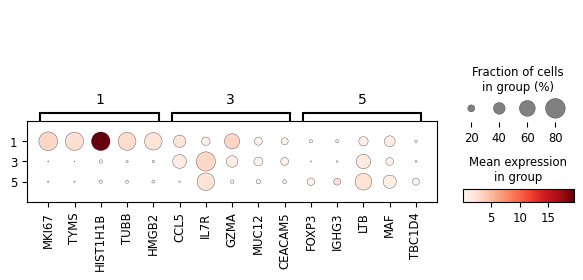

In [8]:
cluster_nums = ['1', '3', '5']

degs = sc_svc_analysis.get_svc_degs(cluster_nums, fc_threshold=1)
marker_dict = (
    degs.groupby('group')['gene']
    .apply(lambda x: x.head(5).tolist())
    .to_dict()
)
sc_svc_analysis.get_dot_plot(cluster_nums, marker_dict)

<Figure size 800x600 with 0 Axes>

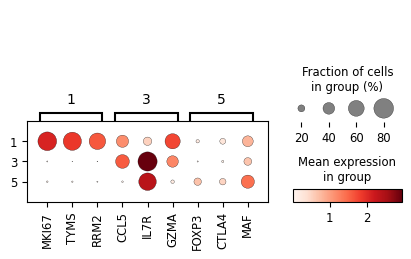

<Figure size 640x480 with 0 Axes>

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.useafm'] = False
plt.figure(figsize=(8, 6))

marker_dict = {
    '1': ['MKI67', 'TYMS', 'RRM2'],
    '3': ['CCL5', 'IL7R', 'GZMA'],
    '5': ['FOXP3', 'CTLA4', 'MAF']
    }

sc_svc_analysis.get_dot_plot(cluster_nums, marker_dict, normalize=True)
plt.savefig(f"{output_dir}/sc_SVC_dotplot.pdf", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

### sc_SVC

Conducting differential expression analysis...
Conducting differential expression analysis...


Conducting differential expression analysis...
Conducting differential expression analysis...


1102

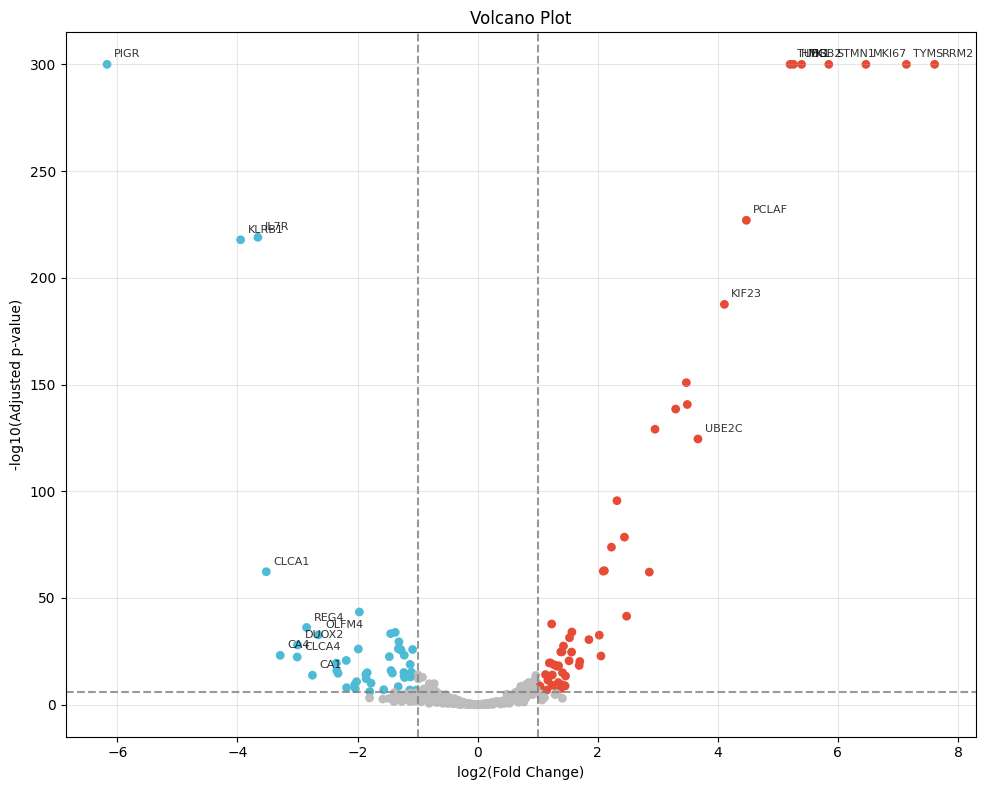

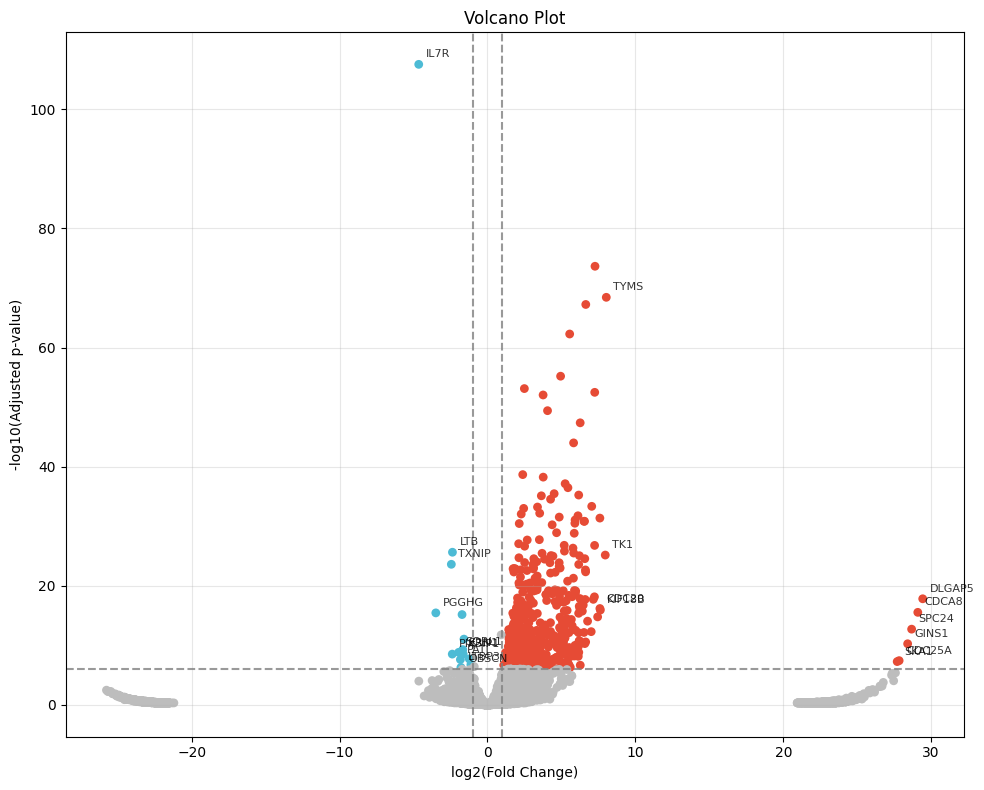

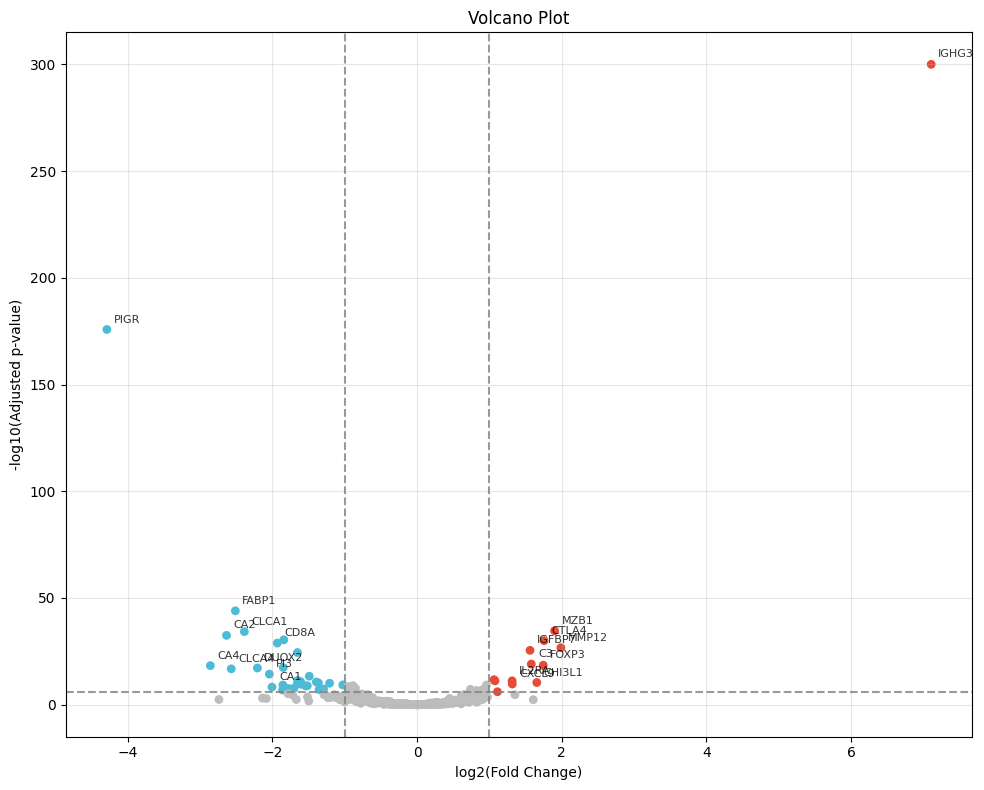

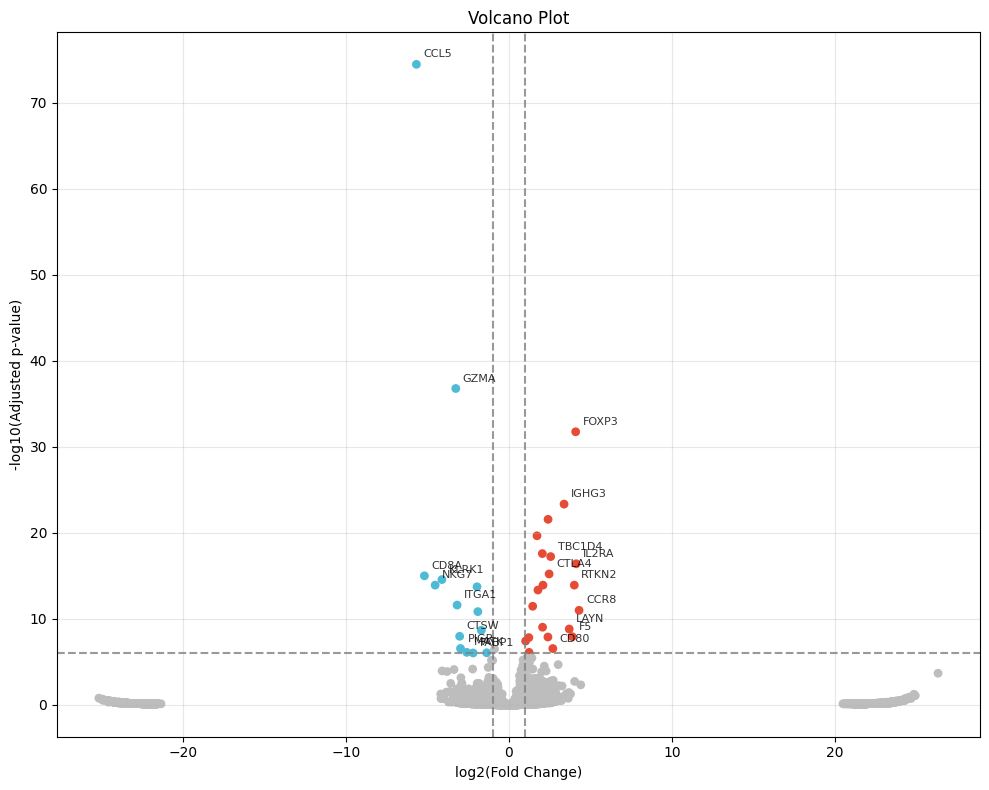

In [10]:
comparison_specs = [("1", "Proliferation"), ("5", "Regulation")]
normal_cluster = "3"
comparison_datasets = {
    "spatial": sc_svc_analysis.sc_SVC_adata_spatial.copy(),
    "expr": sc_svc_analysis.sc_SVC_adata_expr.copy(),
}

from datetime import datetime, timezone
import hashlib
import json
from pathlib import Path
from revise.analysis.bio import get_degs, get_enrichment, plot_volcano

local_resources = [{
    "id": "hallmark_gmt",
    "path": "reproduce/case/pathway/h.all.v2025.1.Hs.symbols.gmt",
    "sha256": hashlib.sha256(Path(geneset_file[0]).read_bytes()).hexdigest(),
}]
local_enrichment_runs = []
for tumor_cluster_num, phenotype in comparison_specs:
    for dataset_name in ("spatial", "expr"):
        comparison_output_dir = f"{output_dir}/comparisons/{phenotype}/{dataset_name}"
        Path(comparison_output_dir).mkdir(parents=True, exist_ok=True)
        comparison_adata = comparison_datasets[dataset_name]
        comparison_adata = comparison_adata[
            comparison_adata.obs["SVC_cluster"].astype(str).isin(
                [normal_cluster, tumor_cluster_num]
            )
        ].copy()
        comparison_adata.obs["SVC_cluster"] = (
            comparison_adata.obs["SVC_cluster"].astype(str).replace({
                normal_cluster: "Normal-infiltrated",
                tumor_cluster_num: "Tumor-infiltrated",
            })
        )
        degs = get_degs(
            comparison_adata,
            groupby="SVC_cluster",
            method="t-test",
            fc_threshold=None,
        )
        degs = degs[degs["group"] == "Tumor-infiltrated"].reset_index(drop=True)
        degs.to_csv(f"{comparison_output_dir}/degs.csv", index=False)
        plot_volcano(
            degs,
            logfc_threshold=1,
            padj_threshold=1e-6,
            top_k=10,
            save_file_name=f"{comparison_output_dir}/volcano.pdf",
        )
        started_at = datetime.now(timezone.utc).isoformat()
        pathway = get_enrichment(
            degs.loc[degs["logfoldchanges"] > 0, "gene"].head(60).tolist(),
            geneset_file,
            background=None,
        )
        pathway.to_csv(f"{comparison_output_dir}/pathway.csv", index=False)
        local_enrichment_runs.append({
            "phenotype": phenotype,
            "dataset": dataset_name,
            "started_at": started_at,
            "completed_at": datetime.now(timezone.utc).isoformat(),
        })

Path(f"{output_dir}/integration-evidence.json").write_text(
    json.dumps({
        "provider": "GSEApy local enrich",
        "background": None,
        "background_policy": "GSEApy default over local GMT union",
        "resources": local_resources,
        "runs": local_enrichment_runs,
    }, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)
